In [15]:

import os
import glob
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.svm import SVC

import cv2
from skimage.feature import hog

In [16]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Check GPU availability
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration complete. Random seed set to:", RANDOM_SEED)

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration complete. Random seed set to: 42


# 2. MOUNT DRIVE AND DEFINE PATHS


In [17]:

from google.colab import drive
drive.mount('/content/drive')

# TCV Dataset path
TCV_PATH = "/content/drive/MyDrive/TCV Dataset"

# Create models directory
os.makedirs("/content/drive/MyDrive/TCV_Models", exist_ok=True)

# Download Kaggle dataset
import kagglehub
KAGGLE_PATH = kagglehub.dataset_download("mostafaabla/garbage-classification")

print(f"Kaggle dataset downloaded to: {KAGGLE_PATH}")
print("Contents:", os.listdir(KAGGLE_PATH))

GARBAGE_ROOT = os.path.join(KAGGLE_PATH, "garbage_classification")
print(f"Garbage classification folder: {GARBAGE_ROOT}")
if os.path.exists(GARBAGE_ROOT):
    print("Classes found:", os.listdir(GARBAGE_ROOT))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'garbage-classification' dataset.
Kaggle dataset downloaded to: /kaggle/input/garbage-classification
Contents: ['garbage_classification']
Garbage classification folder: /kaggle/input/garbage-classification/garbage_classification
Classes found: ['metal', 'white-glass', 'biological', 'paper', 'brown-glass', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic', 'green-glass']


# 3. DATA LOADING & SPLITTING - TCV DATASET


In [18]:

def get_tcv_filepaths_and_labels(tcv_root, use_cropped=True):
    """
    Load TCV dataset filepaths and labels.

    Args:
        tcv_root: Root path to TCV Dataset
        use_cropped: If True, use Cropped subfolder, else use raw

    Returns:
        filepaths: List of image paths
        labels: List of integer labels
        class_names: List of class names in order
        label2name: Dict mapping label index to name
        name2label: Dict mapping name to label index
    """
    # Define class names in alphabetical order for consistency
    class_folders = ["Metal", "Paper", "glass", "Plastic"]
    # Normalize to consistent capitalization
    class_names = ["Glass", "Metal", "Paper", "Plastic"]

    label2name = {i: name for i, name in enumerate(class_names)}
    name2label = {name: i for i, name in enumerate(class_names)}

    filepaths = []
    labels = []
    counts = {}

    for folder_name in class_folders:
        # Map folder name to standardized class name
        if folder_name.lower() == "glass":
            class_name = "Glass"
        else:
            class_name = folder_name

        label = name2label[class_name]

        # Construct path
        if use_cropped:
            class_path = os.path.join(tcv_root, folder_name, "Cropped")
        else:
            class_path = os.path.join(tcv_root, folder_name, "raw")

        if not os.path.exists(class_path):
            print(f"Warning: Path does not exist: {class_path}")
            counts[class_name] = 0
            continue

        # Glob all image files
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            image_files.extend(glob.glob(os.path.join(class_path, ext)))

        filepaths.extend(image_files)
        labels.extend([label] * len(image_files))
        counts[class_name] = len(image_files)

    print("\n=== TCV Dataset Loading ===")
    print(f"Total images found: {len(filepaths)}")
    for class_name in class_names:
        print(f"  {class_name}: {counts.get(class_name, 0)} images")

    return filepaths, labels, class_names, label2name, name2label

# Load TCV dataset
tcv_filepaths, tcv_labels, tcv_class_names, tcv_label2name, tcv_name2label = get_tcv_filepaths_and_labels(
    TCV_PATH, use_cropped=True
)

# Split TCV dataset: 70% train, 15% val, 15% test
tcv_train_paths, tcv_temp_paths, tcv_train_labels, tcv_temp_labels = train_test_split(
    tcv_filepaths, tcv_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=tcv_labels
)

tcv_val_paths, tcv_test_paths, tcv_val_labels, tcv_test_labels = train_test_split(
    tcv_temp_paths, tcv_temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=tcv_temp_labels
)

# Print split statistics
print("\n=== TCV Dataset Splits ===")
split_data = []
for split_name, split_labels in [
    ("Train", tcv_train_labels),
    ("Validation", tcv_val_labels),
    ("Test", tcv_test_labels)
]:
    unique, counts = np.unique(split_labels, return_counts=True)
    row = {"Split": split_name, "Total": len(split_labels)}
    for class_idx, count in zip(unique, counts):
        row[tcv_label2name[class_idx]] = count
    split_data.append(row)

tcv_split_df = pd.DataFrame(split_data)
print(tcv_split_df.to_string(index=False))


=== TCV Dataset Loading ===
Total images found: 363
  Glass: 86 images
  Metal: 85 images
  Paper: 98 images
  Plastic: 94 images

=== TCV Dataset Splits ===
     Split  Total  Glass  Metal  Paper  Plastic
     Train    254     60     59     69       66
Validation     54     13     13     14       14
      Test     55     13     13     15       14


# 4. IMAGE PREPROCESSING PIPELINE


In [19]:
def opencv_preprocess(img_np):
    """
    Apply OpenCV preprocessing: CLAHE, Gaussian blur, noise reduction.

    Args:
        img_np: NumPy array image in RGB, float32 [0,1] or uint8

    Returns:
        Preprocessed image as float32 [0,1]
    """
    # Convert to uint8 if needed
    if img_np.dtype == np.float32 or img_np.dtype == np.float64:
        img_uint8 = (img_np * 255).astype(np.uint8)
    else:
        img_uint8 = img_np.astype(np.uint8)

    # Convert to LAB color space
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)

    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])

    # Convert back to RGB
    img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Apply Gaussian blur for noise reduction
    img_blur = cv2.GaussianBlur(img_clahe, (3, 3), 0)

    # Optional: morphological opening to remove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img_morph = cv2.morphologyEx(img_blur, cv2.MORPH_OPEN, kernel)

    # Convert back to float32 [0,1]
    img_final = img_morph.astype(np.float32) / 255.0

    return img_final

def preprocess_image_opencv(image):
    """
    TensorFlow wrapper for OpenCV preprocessing.
    """
    img_processed = tf.numpy_function(opencv_preprocess, [image], tf.float32)
    img_processed.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    return img_processed

def process_path(filepath, label, apply_preprocessing=False):
    """
    Load and preprocess image from filepath.
    """
    # Read image file
    img = tf.io.read_file(filepath)

    # Decode image (handles both JPEG and PNG)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)

    # Ensure RGB
    img.set_shape([None, None, 3])

    # Resize
    img = tf.image.resize(img, IMG_SIZE)

    # Normalize to [0, 1]
    img = img / 255.0

    # Apply OpenCV preprocessing if requested
    if apply_preprocessing:
        img = preprocess_image_opencv(img)

    return img, label

def build_tf_dataset(filepaths, labels, img_size, batch_size, shuffle=True,
                     augment=False, apply_preprocessing=False):
    """
    Build TensorFlow dataset from filepaths and labels.

    Args:
        filepaths: List of image file paths
        labels: List of integer labels
        img_size: Tuple (height, width)
        batch_size: Batch size
        shuffle: Whether to shuffle dataset
        augment: Whether to apply data augmentation
        apply_preprocessing: Whether to apply OpenCV preprocessing

    Returns:
        tf.data.Dataset
    """
    # Create dataset from paths and labels
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    # Shuffle if requested
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=RANDOM_SEED)

    # Map image loading and preprocessing
    ds = ds.map(
        lambda x, y: process_path(x, y, apply_preprocessing=apply_preprocessing),
        num_parallel_calls=AUTOTUNE
    )

    # Apply data augmentation if requested
    if augment:
        data_augmentation = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
        ])
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    # Batch and prefetch
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

# Create TCV datasets WITHOUT preprocessing (RAW)
print("\n=== Creating TCV RAW Datasets ===")
tcv_train_raw = build_tf_dataset(
    tcv_train_paths, tcv_train_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=True, augment=False, apply_preprocessing=False
)
tcv_val_raw = build_tf_dataset(
    tcv_val_paths, tcv_val_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=False, augment=False, apply_preprocessing=False
)
tcv_test_raw = build_tf_dataset(
    tcv_test_paths, tcv_test_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=False, augment=False, apply_preprocessing=False
)

# Create TCV datasets WITH preprocessing (PRE)
print("\n=== Creating TCV PREPROCESSED Datasets ===")
tcv_train_pre = build_tf_dataset(
    tcv_train_paths, tcv_train_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=True, augment=True, apply_preprocessing=True
)
tcv_val_pre = build_tf_dataset(
    tcv_val_paths, tcv_val_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=False, augment=False, apply_preprocessing=True
)
tcv_test_pre = build_tf_dataset(
    tcv_test_paths, tcv_test_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=False, augment=False, apply_preprocessing=True
)

print("TCV datasets created successfully!")


=== Creating TCV RAW Datasets ===

=== Creating TCV PREPROCESSED Datasets ===
TCV datasets created successfully!


# 5. DATA LOADING - KAGGLE DATASET


In [20]:

print("\n=== Loading Kaggle Dataset ===")

# Load training dataset
kaggle_train_ds = tf.keras.utils.image_dataset_from_directory(
    GARBAGE_ROOT,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Load validation dataset
kaggle_val_full = tf.keras.utils.image_dataset_from_directory(
    GARBAGE_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Get class names
kaggle_class_names = kaggle_train_ds.class_names
print(f"Kaggle classes: {kaggle_class_names}")

# Split validation into val and test (50-50)
val_batches = tf.data.experimental.cardinality(kaggle_val_full)
kaggle_val_ds = kaggle_val_full.take(val_batches // 2)
kaggle_test_ds = kaggle_val_full.skip(val_batches // 2)

# Normalize images to [0, 1]
normalization_layer = layers.Rescaling(1./255)

kaggle_train_ds = kaggle_train_ds.map(lambda x, y: (normalization_layer(x), y))
kaggle_val_ds = kaggle_val_ds.map(lambda x, y: (normalization_layer(x), y))
kaggle_test_ds = kaggle_test_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
kaggle_train_ds = kaggle_train_ds.prefetch(AUTOTUNE)
kaggle_val_ds = kaggle_val_ds.prefetch(AUTOTUNE)
kaggle_test_ds = kaggle_test_ds.prefetch(AUTOTUNE)

print("Kaggle datasets loaded successfully!")



=== Loading Kaggle Dataset ===
Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.
Kaggle classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Kaggle datasets loaded successfully!


# 6. FEATURE-BASED MODEL: HOG + SVM



=== Training HOG + SVM Model ===
Extracting HOG features for training set...
Train HOG features shape: (254, 8100)
Extracting HOG features for validation set...
Val HOG features shape: (54, 8100)
Extracting HOG features for test set...
Test HOG features shape: (55, 8100)

Training SVM classifier...
SVM training complete!

Evaluating SVM on test set...
HOG+SVM Test Accuracy: 0.8727
Macro Precision: 0.8727
Macro Recall: 0.8668
Macro F1: 0.8573

Classification Report:
              precision    recall  f1-score   support

       Glass       0.87      1.00      0.93        13
       Metal       0.88      0.54      0.67        13
       Paper       0.88      1.00      0.94        15
     Plastic       0.87      0.93      0.90        14

    accuracy                           0.87        55
   macro avg       0.87      0.87      0.86        55
weighted avg       0.87      0.87      0.86        55



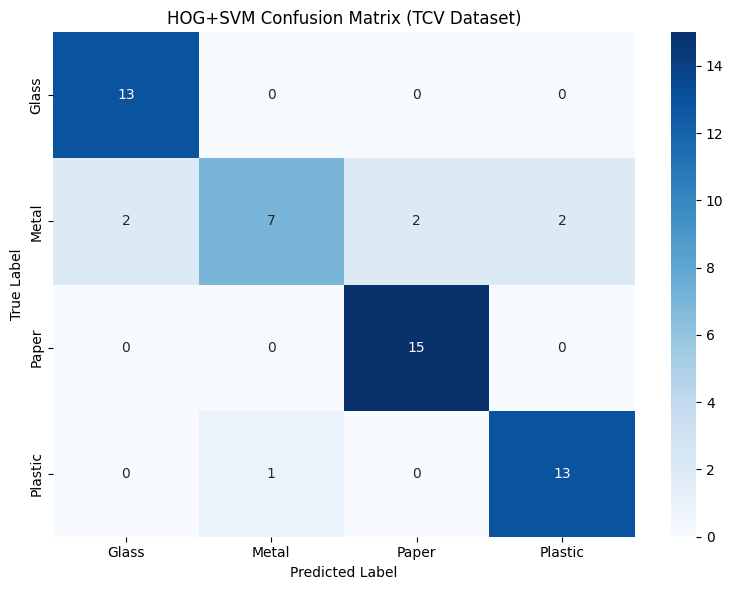

In [21]:

print("\n=== Training HOG + SVM Model ===")

def load_and_preprocess_for_hog(path):
    """
    Load image and preprocess for HOG feature extraction.

    Args:
        path: Image file path

    Returns:
        Grayscale image resized to (128, 128)
    """
    img = cv2.imread(path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    return img_gray

def extract_hog_features(image_gray):
    """
    Extract HOG features from grayscale image.

    Args:
        image_gray: Grayscale image array

    Returns:
        HOG feature vector
    """
    features = hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return features

# Extract HOG features for TCV train set
print("Extracting HOG features for training set...")
X_train_hog = []
y_train_hog = []
for path, label in zip(tcv_train_paths, tcv_train_labels):
    img_gray = load_and_preprocess_for_hog(path)
    if img_gray is not None:
        features = extract_hog_features(img_gray)
        X_train_hog.append(features)
        y_train_hog.append(label)

X_train_hog = np.array(X_train_hog)
y_train_hog = np.array(y_train_hog)
print(f"Train HOG features shape: {X_train_hog.shape}")

# Extract HOG features for TCV validation set
print("Extracting HOG features for validation set...")
X_val_hog = []
y_val_hog = []
for path, label in zip(tcv_val_paths, tcv_val_labels):
    img_gray = load_and_preprocess_for_hog(path)
    if img_gray is not None:
        features = extract_hog_features(img_gray)
        X_val_hog.append(features)
        y_val_hog.append(label)

X_val_hog = np.array(X_val_hog)
y_val_hog = np.array(y_val_hog)
print(f"Val HOG features shape: {X_val_hog.shape}")

# Extract HOG features for TCV test set
print("Extracting HOG features for test set...")
X_test_hog = []
y_test_hog = []
for path, label in zip(tcv_test_paths, tcv_test_labels):
    img_gray = load_and_preprocess_for_hog(path)
    if img_gray is not None:
        features = extract_hog_features(img_gray)
        X_test_hog.append(features)
        y_test_hog.append(label)

X_test_hog = np.array(X_test_hog)
y_test_hog = np.array(y_test_hog)
print(f"Test HOG features shape: {X_test_hog.shape}")

# Train SVM classifier
print("\nTraining SVM classifier...")
svm_classifier = SVC(kernel='linear', probability=True, random_state=RANDOM_SEED)
svm_classifier.fit(X_train_hog, y_train_hog)
print("SVM training complete!")

# Evaluate on test set
print("\nEvaluating SVM on test set...")
y_pred_hog = svm_classifier.predict(X_test_hog)

# Calculate metrics
hog_accuracy = accuracy_score(y_test_hog, y_pred_hog)
hog_precision, hog_recall, hog_f1, _ = precision_recall_fscore_support(
    y_test_hog, y_pred_hog, average='macro'
)
hog_precision_w, hog_recall_w, hog_f1_w, _ = precision_recall_fscore_support(
    y_test_hog, y_pred_hog, average='weighted'
)

print(f"HOG+SVM Test Accuracy: {hog_accuracy:.4f}")
print(f"Macro Precision: {hog_precision:.4f}")
print(f"Macro Recall: {hog_recall:.4f}")
print(f"Macro F1: {hog_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_hog, y_pred_hog, target_names=tcv_class_names))

# Confusion matrix
cm_hog = confusion_matrix(y_test_hog, y_pred_hog)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hog, annot=True, fmt='d', cmap='Blues',
            xticklabels=tcv_class_names, yticklabels=tcv_class_names)
plt.title('HOG+SVM Confusion Matrix (TCV Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Store results
results_hog_svm = {
    "model_name": "HOG+SVM",
    "dataset": "TCV",
    "preprocessing": "hog",
    "test_accuracy": hog_accuracy,
    "test_precision_macro": hog_precision,
    "test_recall_macro": hog_recall,
    "test_f1_macro": hog_f1,
    "test_f1_weighted": hog_f1_w
}


# 7. DEEP LEARNING MODELS - MODEL BUILDERS


In [22]:

def build_mobilenet_model(num_classes):
    """
    Build MobileNetV2 transfer learning model.

    Args:
        num_classes: Number of output classes

    Returns:
        Keras model
    """
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze base model
    base_model.trainable = False

    # Build model
    model = models.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

def build_resnet_model(num_classes):
    """
    Build ResNet50 transfer learning model.

    Args:
        num_classes: Number of output classes

    Returns:
        Keras model
    """
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze base model
    base_model.trainable = False

    # Build model
    model = models.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

# 8. TRAINING AND EVALUATION FUNCTION


In [23]:

def train_and_evaluate_keras_model(model, train_ds, val_ds, test_ds, class_names,
                                   model_name, dataset_name, preprocessing_flag):
    """
    Train and evaluate a Keras model.

    Args:
        model: Keras model to train
        train_ds: Training dataset
        val_ds: Validation dataset
        test_ds: Test dataset
        class_names: List of class names
        model_name: Name of the model (e.g., "MobileNetV2")
        dataset_name: Name of the dataset (e.g., "TCV")
        preprocessing_flag: "raw" or "opencv+aug"

    Returns:
        Dictionary with results
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name} on {dataset_name} ({preprocessing_flag})")
    print(f"{'='*60}")

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    model_path = f"/content/drive/MyDrive/TCV_Models/{model_name}_{dataset_name}_{preprocessing_flag}.h5"
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            model_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Get predictions for detailed metrics
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate metrics
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix\n{dataset_name} - {preprocessing_flag}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy\n{dataset_name} - {preprocessing_flag}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss\n{dataset_name} - {preprocessing_flag}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Return results dictionary
    results = {
        "model_name": model_name,
        "dataset": dataset_name,
        "preprocessing": preprocessing_flag,
        "test_accuracy": test_accuracy,
        "test_precision_macro": precision_macro,
        "test_recall_macro": recall_macro,
        "test_f1_macro": f1_macro,
        "test_f1_weighted": f1_weighted
    }

    print(f"\nModel saved to: {model_path}")

    return results


# 9. TRAIN ALL MODELS



EXPERIMENT 1: MobileNetV2 on RAW TCV Dataset

Training MobileNetV2 on TCV (raw)
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.2435 - loss: 1.9477
Epoch 1: val_accuracy improved from -inf to 0.40741, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.2432 - loss: 1.9394 - val_accuracy: 0.4074 - val_loss: 1.3180
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3548 - loss: 1.5748
Epoch 2: val_accuracy improved from 0.40741 to 0.61111, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.3548 - loss: 1.5635 - val_accuracy: 0.6111 - val_loss: 1.1019
Epoch 3/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4305 - loss: 1.1486
Epoch 3: val_accuracy improved from 0.61111 to 0.72222, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4328 - loss: 1.1565 - val_accuracy: 0.7222 - val_loss: 0.9225
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5854 - loss: 0.9537
Epoch 4: val_accuracy improved from 0.72222 to 0.74074, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5847 - loss: 0.9565 - val_accuracy: 0.7407 - val_loss: 0.7937
Epoch 5/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6631 - loss: 0.8208
Epoch 5: val_accuracy improved from 0.74074 to 0.83333, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6723 - loss: 0.8037 - val_accuracy: 0.8333 - val_loss: 0.6961
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7022 - loss: 0.7322
Epoch 6: val_accuracy did not improve from 0.83333
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7064 - loss: 0.7249 - val_accuracy: 0.8333 - val_loss: 0.6240
Epoch 7/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7740 - loss: 0.6080
Epoch 7: val_accuracy improved from 0.83333 to 0.87037, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.7831 - loss: 0.5991 - val_accuracy: 0.8704 - val_loss: 0.5589
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8682 - loss: 0.4863
Epoch 8: val_accuracy did not improve from 0.87037
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8658 - loss: 0.4884 - val_accuracy: 0.8704 - val_loss: 0.5095
Epoch 9/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8857 - loss: 0.4482
Epoch 9: val_accuracy did not improve from 0.87037
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8849 - loss: 0.4477 - val_accuracy: 0.8704 - val_loss: 0.4707
Epoch 10/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8101 - loss: 0.5018
Epoch 10: val_accuracy did not improve from 0.87037
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8156 - loss: 0.4901 - val_accuracy: 0.8704 - val_loss: 0.4386
Epoch 11/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9105 - loss: 0.3440
Epoch 11: val_accuracy improved from 0.87037 to 0.88889

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9076 - loss: 0.3457 - val_accuracy: 0.8889 - val_loss: 0.4119
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9552 - loss: 0.2781
Epoch 12: val_accuracy did not improve from 0.88889
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9549 - loss: 0.2802 - val_accuracy: 0.8889 - val_loss: 0.3898
Epoch 13/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9535 - loss: 0.2656
Epoch 13: val_accuracy did not improve from 0.88889
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9498 - loss: 0.2687 - val_accuracy: 0.8704 - val_loss: 0.3715
Epoch 14/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9197 - loss: 0.3054
Epoch 14: val_accuracy did not improve from 0.88889
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9227 - loss: 0.2993 - val_accuracy: 0.8704 - val_loss: 0.3590
Epoch 15/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9746 - loss: 0.2061
Epoch 15: val_accuracy did not improve from 0.88889

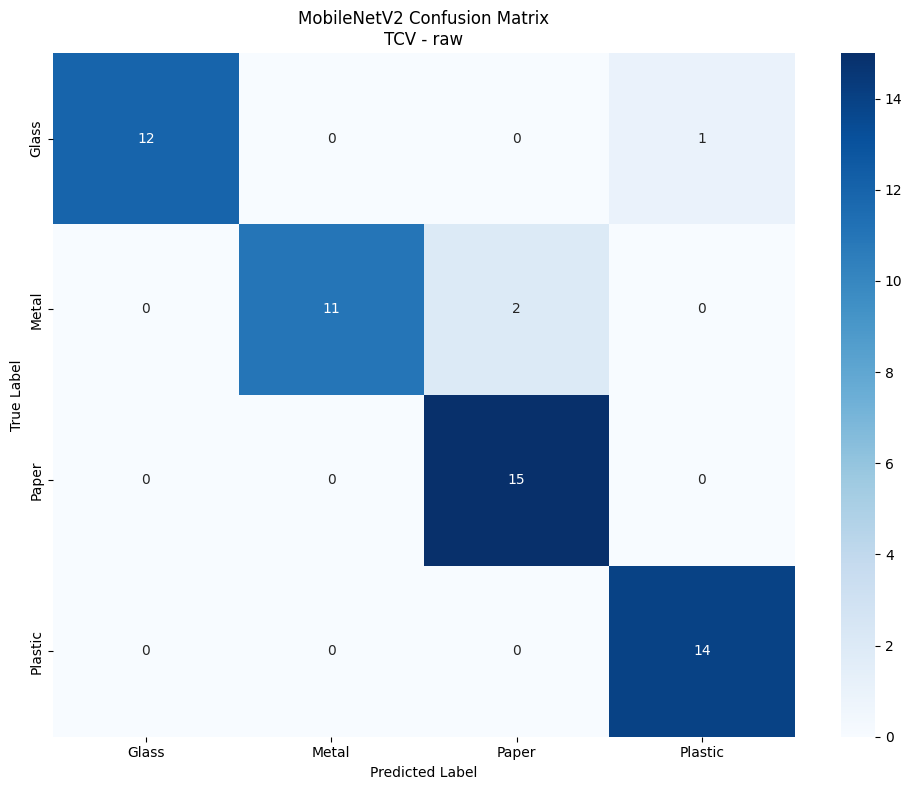

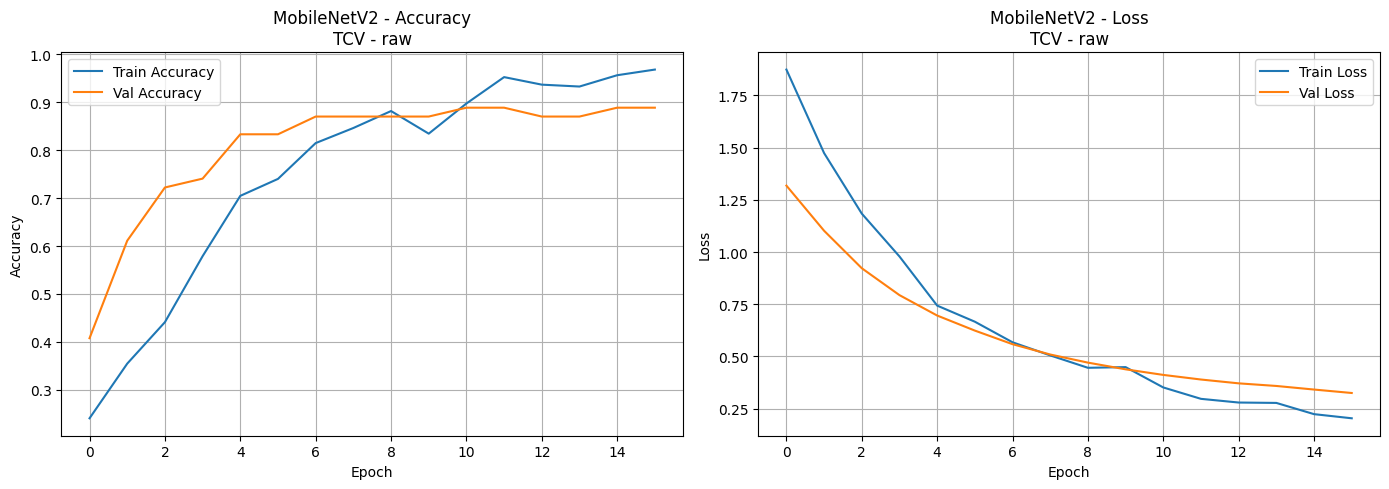


Model saved to: /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_raw.h5

EXPERIMENT 2: MobileNetV2 on PREPROCESSED TCV Dataset

Training MobileNetV2 on TCV (opencv+aug)
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.2542 - loss: 1.7950
Epoch 1: val_accuracy improved from -inf to 0.37037, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.2605 - loss: 1.7833 - val_accuracy: 0.3704 - val_loss: 1.3347
Epoch 2/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4066 - loss: 1.3968
Epoch 2: val_accuracy improved from 0.37037 to 0.44444, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.4011 - loss: 1.4090 - val_accuracy: 0.4444 - val_loss: 1.1091
Epoch 3/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5779 - loss: 0.9572
Epoch 3: val_accuracy improved from 0.44444 to 0.68519, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5676 - loss: 0.9752 - val_accuracy: 0.6852 - val_loss: 0.9560
Epoch 4/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6115 - loss: 0.9548
Epoch 4: val_accuracy improved from 0.68519 to 0.75926, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.6007 - loss: 0.9684 - val_accuracy: 0.7593 - val_loss: 0.8587
Epoch 5/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6175 - loss: 0.8734
Epoch 5: val_accuracy did not improve from 0.75926
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6185 - loss: 0.8803 - val_accuracy: 0.7593 - val_loss: 0.7743
Epoch 6/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6474 - loss: 0.7969
Epoch 6: val_accuracy improved from 0.75926 to 0.83333, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.6453 - loss: 0.7999 - val_accuracy: 0.8333 - val_loss: 0.7013
Epoch 7/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7178 - loss: 0.7106
Epoch 7: val_accuracy did not improve from 0.83333
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.7237 - loss: 0.7080 - val_accuracy: 0.8148 - val_loss: 0.6443
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8114 - loss: 0.5846
Epoch 8: val_accuracy improved from 0.83333 to 0.85185, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.8083 - loss: 0.5854 - val_accuracy: 0.8519 - val_loss: 0.5983
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7662 - loss: 0.5883
Epoch 9: val_accuracy did not improve from 0.85185
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.7659 - loss: 0.5898 - val_accuracy: 0.8333 - val_loss: 0.5650
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8686 - loss: 0.4332
Epoch 10: val_accuracy improved from 0.85185 to 0.88889, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.8674 - loss: 0.4359 - val_accuracy: 0.8889 - val_loss: 0.5282
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8557 - loss: 0.4254
Epoch 11: val_accuracy improved from 0.88889 to 0.92593, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.8547 - loss: 0.4275 - val_accuracy: 0.9259 - val_loss: 0.4896
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8890 - loss: 0.3983
Epoch 12: val_accuracy did not improve from 0.92593
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8873 - loss: 0.4014 - val_accuracy: 0.9074 - val_loss: 0.4695
Epoch 13/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9001 - loss: 0.3557
Epoch 13: val_accuracy did not improve from 0.92593
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8995 - loss: 0.3554 - val_accuracy: 0.9074 - val_loss: 0.4497
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8526 - loss: 0.3804
Epoch 14: val_accuracy did not improve from 0.92593
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8559 - loss: 0.3781 - val_accuracy: 0.8889 - val_loss: 0.4336
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9290 - loss: 0.2816
Epoch 15: val_accuracy did not improve from 0.92

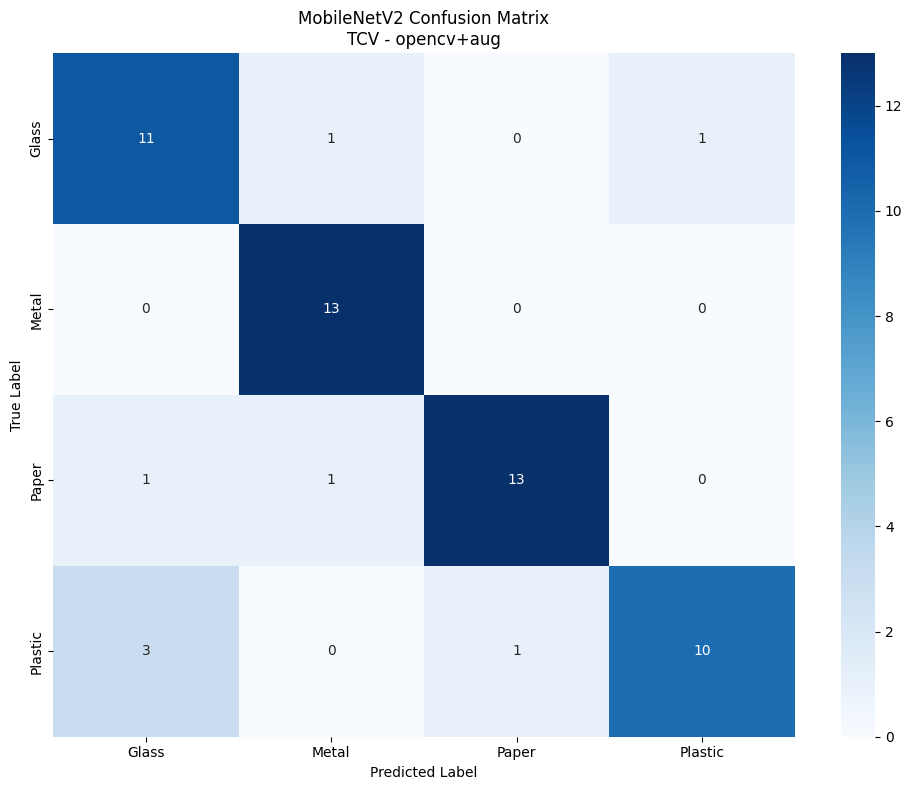

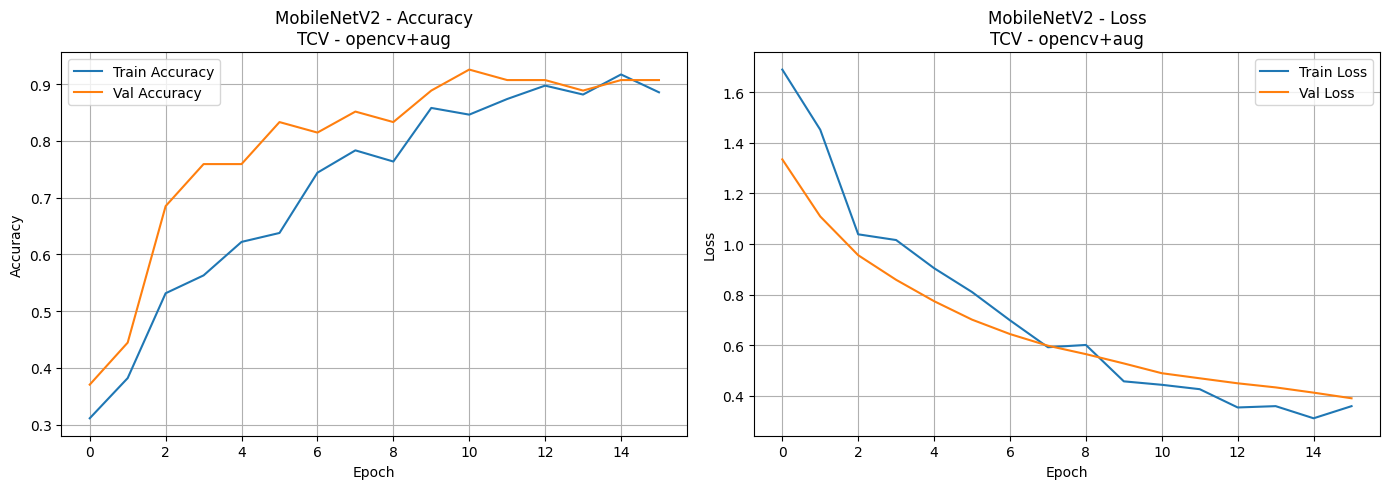


Model saved to: /content/drive/MyDrive/TCV_Models/MobileNetV2_TCV_opencv+aug.h5

EXPERIMENT 3: ResNet50 on PREPROCESSED TCV Dataset

Training ResNet50 on TCV (opencv+aug)
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.2902 - loss: 1.8894
Epoch 1: val_accuracy improved from -inf to 0.25926, saving model to /content/drive/MyDrive/TCV_Models/ResNet50_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2890 - loss: 1.8845 - val_accuracy: 0.2593 - val_loss: 1.5197
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.2530 - loss: 1.6927
Epoch 2: val_accuracy did not improve from 0.25926
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.2542 - loss: 1.6889 - val_accuracy: 0.2593 - val_loss: 1.4058
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1943 - loss: 1.7425
Epoch 3: val_accuracy improved from 0.25926 to 0.31481, saving model to /content/drive/MyDrive/TCV_Models/ResNet50_TCV_opencv+aug.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.1946 - loss: 1.7377 - val_accuracy: 0.3148 - val_loss: 1.3818
Epoch 4/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2804 - loss: 1.5758
Epoch 4: val_accuracy did not improve from 0.31481
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.2855 - loss: 1.5615 - val_accuracy: 0.2407 - val_loss: 1.3842
Epoch 5/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2209 - loss: 1.6077
Epoch 5: val_accuracy did not improve from 0.31481
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.2243 - loss: 1.6130 - val_accuracy: 0.3148 - val_loss: 1.3799
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2432 - loss: 1.5406
Epoch 6: val_accuracy did not improve from 0.31481
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.2424 - loss: 1.5431 - val_accuracy: 0.2963 - val_loss: 1.3781
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2800 - loss: 1.5273
Epoch 7: val_accuracy did not improve from 0.31481
8/8 

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.2542 - loss: 1.5192 - val_accuracy: 0.3889 - val_loss: 1.3745
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2780 - loss: 1.4505
Epoch 9: val_accuracy did not improve from 0.38889
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.2812 - loss: 1.4498 - val_accuracy: 0.3704 - val_loss: 1.3749
Epoch 10/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2618 - loss: 1.4967
Epoch 10: val_accuracy did not improve from 0.38889
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.2684 - loss: 1.4891 - val_accuracy: 0.3889 - val_loss: 1.3726
Epoch 11/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2347 - loss: 1.6012
Epoch 11: val_accuracy did not improve from 0.38889
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2394 - loss: 1.5905 - val_accuracy: 0.3148 - val_loss: 1.3716
Epoch 12/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2551 - loss: 1.4842
Epoch 12: val_accuracy did not improve from 0.3888

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Macro Precision: 0.1621
Macro Recall: 0.3131
Macro F1: 0.2133

Classification Report:
              precision    recall  f1-score   support

       Glass       0.00      0.00      0.00        13
       Metal       0.00      0.00      0.00        13
       Paper       0.27      0.47      0.34        15
     Plastic       0.38      0.79      0.51        14

    accuracy                           0.33        55
   macro avg       0.16      0.31      0.21        55
weighted avg       0.17      0.33      0.22        55



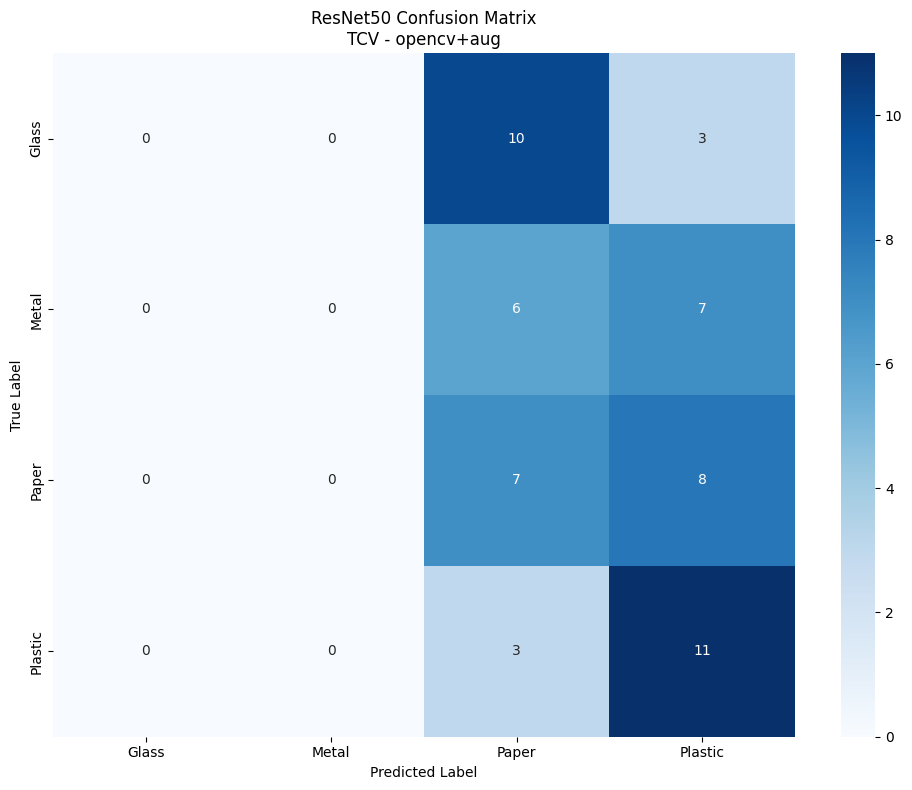

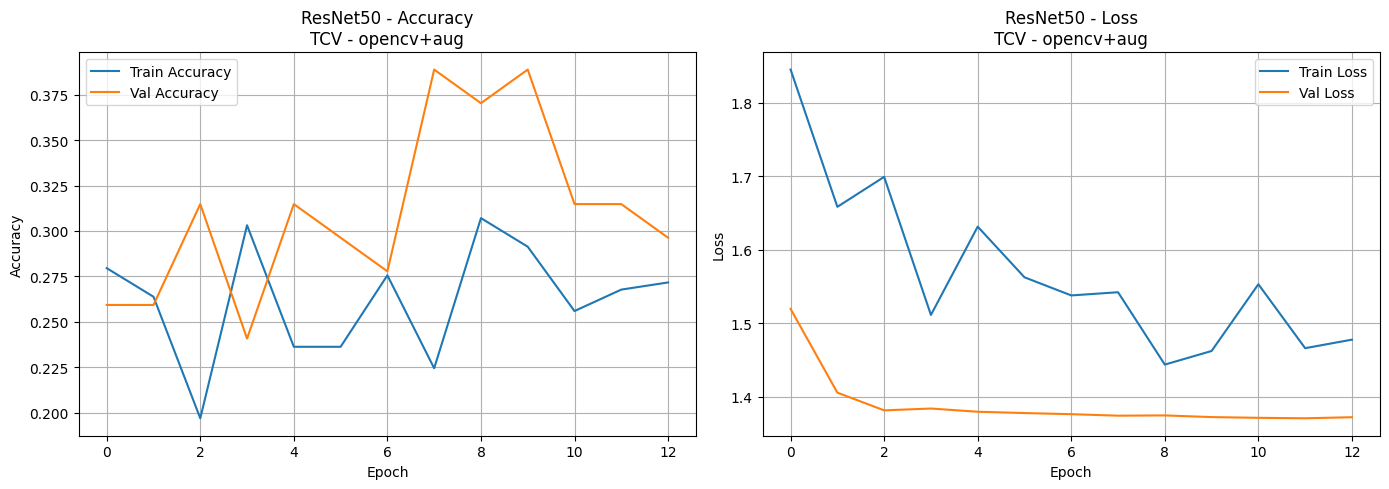


Model saved to: /content/drive/MyDrive/TCV_Models/ResNet50_TCV_opencv+aug.h5

EXPERIMENT 4: MobileNetV2 on Kaggle Dataset

Training MobileNetV2 on Kaggle (rescale)
Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5745 - loss: 1.4298
Epoch 1: val_accuracy improved from -inf to 0.89779, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.5748 - loss: 1.4286 - val_accuracy: 0.8978 - val_loss: 0.4198
Epoch 2/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8467 - loss: 0.5042
Epoch 2: val_accuracy improved from 0.89779 to 0.91992, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8469 - loss: 0.5036 - val_accuracy: 0.9199 - val_loss: 0.2957
Epoch 3/20
386/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8875 - loss: 0.3685
Epoch 3: val_accuracy improved from 0.91992 to 0.93164, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8875 - loss: 0.3683 - val_accuracy: 0.9316 - val_loss: 0.2402
Epoch 4/20
384/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9077 - loss: 0.3010
Epoch 4: val_accuracy improved from 0.93164 to 0.93945, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9077 - loss: 0.3008 - val_accuracy: 0.9395 - val_loss: 0.2305
Epoch 5/20
384/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9179 - loss: 0.2569
Epoch 5: val_accuracy improved from 0.93945 to 0.94141, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


...

388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9625 - loss: 0.1322 - val_accuracy: 0.9453 - val_loss: 0.1686
Epoch 12/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9615 - loss: 0.1231
Epoch 12: val_accuracy did not improve from 0.94531
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9615 - loss: 0.1231 - val_accuracy: 0.9427 - val_loss: 0.1826
Epoch 13/20
386/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9655 - loss: 0.1156
Epoch 13: val_accuracy improved from 0.94531 to 0.94596, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9655 - loss: 0.1155 - val_accuracy: 0.9460 - val_loss: 0.1732
Epoch 14/20
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9667 - loss: 0.1123
Epoch 14: val_accuracy did not improve from 0.94596
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9667 - loss: 0.1123 - val_accuracy: 0.9460 - val_loss: 0.1679
Epoch 15/20
384/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9730 - loss: 0.0934
Epoch 15: val_accuracy improved from 0.94596 to 0.95117, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9730 - loss: 0.0934 - val_accuracy: 0.9512 - val_loss: 0.1686
Epoch 16/20
386/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9738 - loss: 0.0869
Epoch 16: val_accuracy did not improve from 0.95117
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9738 - loss: 0.0869 - val_accuracy: 0.9499 - val_loss: 0.1658
Epoch 17/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9774 - loss: 0.0819
Epoch 17: val_accuracy did not improve from 0.95117
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9775 - loss: 0.0819 - val_accuracy: 0.9473 - val_loss: 0.1682
Epoch 18/20
386/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9794 - loss: 0.0766
Epoch 18: val_accuracy improved from 0.95117 to 0.95312, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9794 - loss: 0.0765 - val_accuracy: 0.9531 - val_loss: 0.1605
Epoch 19/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9769 - loss: 0.0716
Epoch 19: val_accuracy did not improve from 0.95312
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9770 - loss: 0.0716 - val_accuracy: 0.9499 - val_loss: 0.1690
Epoch 20/20
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9830 - loss: 0.0632
Epoch 20: val_accuracy improved from 0.95312 to 0.95443, saving model to /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9830 - loss: 0.0632 - val_accuracy: 0.9544 - val_loss: 0.1656
Restoring model weights from the end of the best epoch: 20.

Evaluating on test set...
Test Loss: 0.1498
Test Accuracy: 0.9528
Macro Precision: 0.9307
Macro Recall: 0.9289
Macro F1: 0.9293

Classification Report:
              precision    recall  f1-score   support

     battery       0.95      0.98      0.96        89
  biological       0.99      0.97      0.98        95
 brown-glass       0.87      0.94      0.90        48
   cardboard       0.91      0.91      0.91        92
     clothes       0.99      0.99      0.99       567
 green-glass       0.92      0.91      0.92        54
       metal       0.92      0.92      0.92        72
       paper       0.91      0.94      0.93       112
     plastic       0.87      0.85      0.86       100
       shoes       0.95      0.99      0.97       195
       trash       0.96      0.94      0.95        72
 white-glass       0

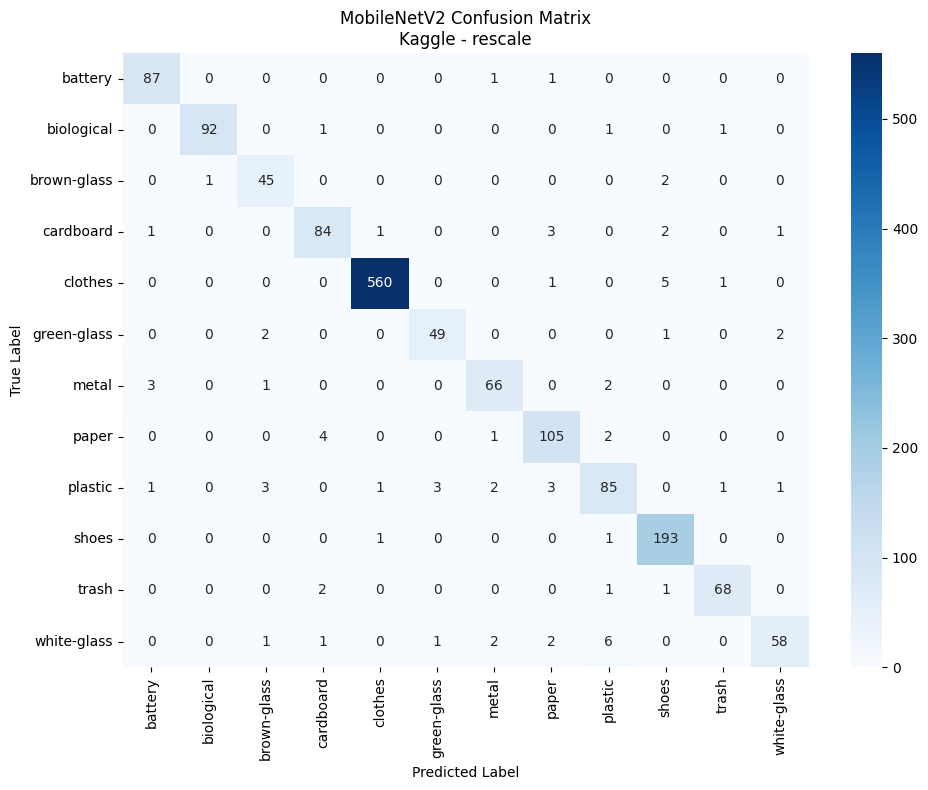

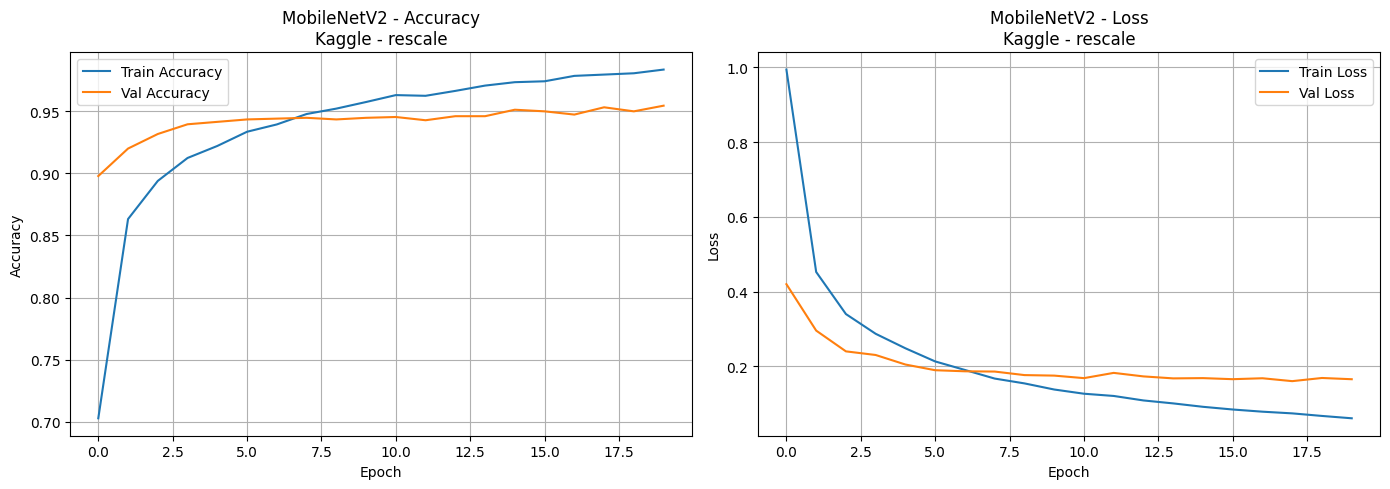


Model saved to: /content/drive/MyDrive/TCV_Models/MobileNetV2_Kaggle_rescale.h5

EXPERIMENT 5: EfficientNetB0 on Kaggle Dataset

Training EfficientNetB0 on Kaggle (rescale)
Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3413 - loss: 2.2239
Epoch 1: val_accuracy improved from -inf to 0.32096, saving model to /content/drive/MyDrive/TCV_Models/EfficientNetB0_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3413 - loss: 2.2239 - val_accuracy: 0.3210 - val_loss: 2.2008
Epoch 2/20
384/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3482 - loss: 2.1969
Epoch 2: val_accuracy improved from 0.32096 to 0.32161, saving model to /content/drive/MyDrive/TCV_Models/EfficientNetB0_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3481 - loss: 2.1970 - val_accuracy: 0.3216 - val_loss: 2.2030
Epoch 3/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3479 - loss: 2.1986
Epoch 3: val_accuracy did not improve from 0.32161
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3479 - loss: 2.1987 - val_accuracy: 0.3171 - val_loss: 2.2122
Epoch 4/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3490 - loss: 2.1956
Epoch 4: val_accuracy improved from 0.32161 to 0.32812, saving model to /content/drive/MyDrive/TCV_Models/EfficientNetB0_Kaggle_rescale.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3489 - loss: 2.1957 - val_accuracy: 0.3281 - val_loss: 2.1936
Epoch 5/20
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3493 - loss: 2.1968
Epoch 5: val_accuracy did not improve from 0.32812
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3493 - loss: 2.1969 - val_accuracy: 0.3229 - val_loss: 2.2035
Epoch 6/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3479 - loss: 2.1944
Epoch 6: val_accuracy did not improve from 0.32812
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3479 - loss: 2.1945 - val_accuracy: 0.3216 - val_loss: 2.2026
Epoch 7/20
384/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3476 - loss: 2.1939
Epoch 7: val_accuracy did not improve from 0.32812
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3476 - loss: 2.1940 - val_accuracy: 0.3249 - val_loss: 2.2000
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3486 - loss: 2.1888
Epoch 8: val_accuracy impro

388/388 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3486 - loss: 2.1888 - val_accuracy: 0.3288 - val_loss: 2.1939
Epoch 9/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3476 - loss: 2.1877
Epoch 9: val_accuracy did not improve from 0.32878
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3476 - loss: 2.1877 - val_accuracy: 0.3223 - val_loss: 2.2059
Epoch 10/20
385/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3486 - loss: 2.1908
Epoch 10: val_accuracy did not improve from 0.32878
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3485 - loss: 2.1909 - val_accuracy: 0.3229 - val_loss: 2.2012
Epoch 11/20
386/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3482 - loss: 2.1849
Epoch 11: val_accuracy did not improve from 0.32878
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3481 - loss: 2.1850 - val_accuracy: 0.3203 - val_loss: 2.2041
Epoch 12/20
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3497 - loss: 2.1884
Epoch 12: val_accuracy

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Macro Precision: 0.0303
Macro Recall: 0.0833
Macro F1: 0.0445

Classification Report:
              precision    recall  f1-score   support

     battery       0.00      0.00      0.00        88
  biological       0.00      0.00      0.00        96
 brown-glass       0.00      0.00      0.00        56
   cardboard       0.00      0.00      0.00        88
     clothes       0.36      1.00      0.53       570
 green-glass       0.00      0.00      0.00        53
       metal       0.00      0.00      0.00        71
       paper       0.00      0.00      0.00       114
     plastic       0.00      0.00      0.00        94
       shoes       0.00      0.00      0.00       191
       trash       0.00      0.00      0.00        76
 white-glass       0.00      0.00      0.00        70

    accuracy                           0.36      1567
   macro avg       0.03      0.08      0.04      1567
weighted avg       0.13      0.36      0.19      1567



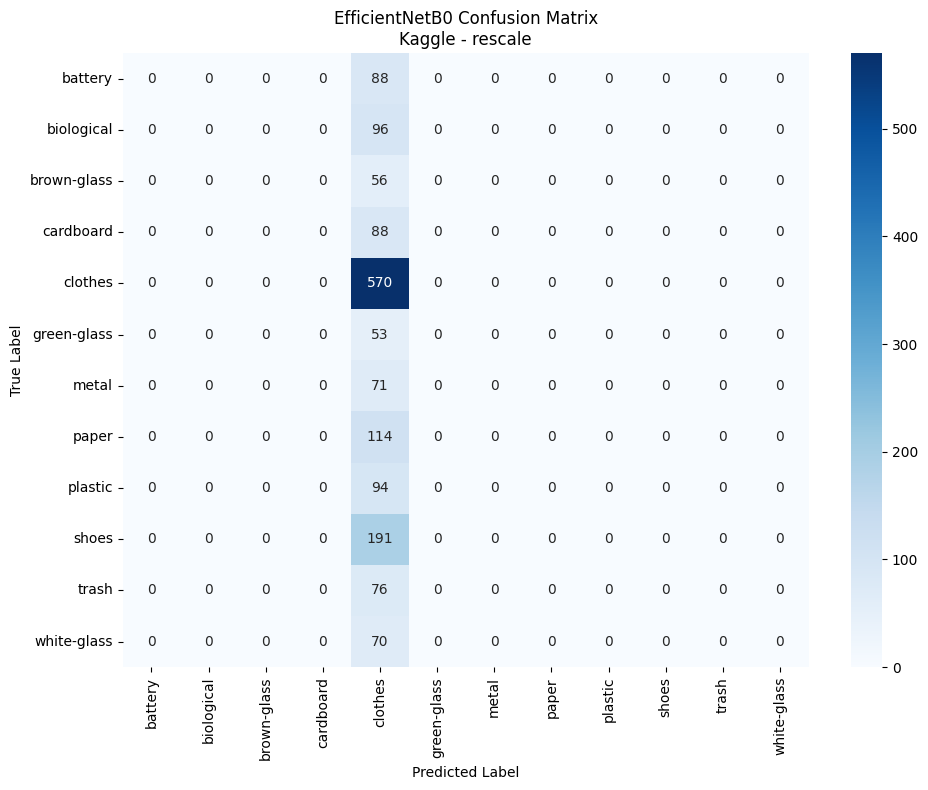

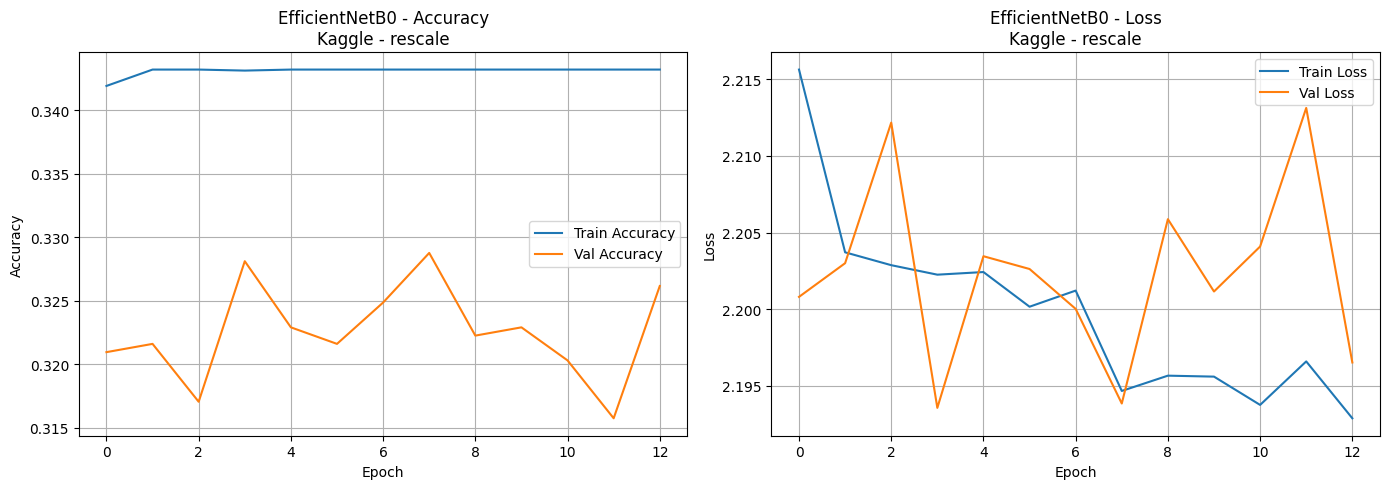


Model saved to: /content/drive/MyDrive/TCV_Models/EfficientNetB0_Kaggle_rescale.h5


In [24]:
all_results = []

# Import EfficientNetB0 here so you don't have to touch other cells
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_model(num_classes):
    """
    Build EfficientNetB0 transfer learning model for Kaggle.
    Lighter and usually faster than ResNet50.
    """
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze base
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# ====================================================
# A) TCV DATASET EXPERIMENTS
# ====================================================

# A1) MobileNetV2 on RAW TCV
print("\n" + "="*60)
print("EXPERIMENT 1: MobileNetV2 on RAW TCV Dataset")
print("="*60)
model_mobilenet_tcv_raw = build_mobilenet_model(num_classes=len(tcv_class_names))
results_1 = train_and_evaluate_keras_model(
    model_mobilenet_tcv_raw,
    tcv_train_raw,
    tcv_val_raw,
    tcv_test_raw,
    tcv_class_names,
    "MobileNetV2",
    "TCV",
    "raw"
)
all_results.append(results_1)

# A2) MobileNetV2 on PREPROCESSED TCV
print("\n" + "="*60)
print("EXPERIMENT 2: MobileNetV2 on PREPROCESSED TCV Dataset")
print("="*60)
model_mobilenet_tcv_pre = build_mobilenet_model(num_classes=len(tcv_class_names))
results_2 = train_and_evaluate_keras_model(
    model_mobilenet_tcv_pre,
    tcv_train_pre,
    tcv_val_pre,
    tcv_test_pre,
    tcv_class_names,
    "MobileNetV2",
    "TCV",
    "opencv+aug"
)
all_results.append(results_2)

# A3) ResNet50 on PREPROCESSED TCV
print("\n" + "="*60)
print("EXPERIMENT 3: ResNet50 on PREPROCESSED TCV Dataset")
print("="*60)
model_resnet_tcv_pre = build_resnet_model(num_classes=len(tcv_class_names))
results_3 = train_and_evaluate_keras_model(
    model_resnet_tcv_pre,
    tcv_train_pre,
    tcv_val_pre,
    tcv_test_pre,
    tcv_class_names,
    "ResNet50",
    "TCV",
    "opencv+aug"
)
all_results.append(results_3)

# ====================================================
# B) KAGGLE DATASET EXPERIMENTS
# ====================================================

# B1) MobileNetV2 on Kaggle
print("\n" + "="*60)
print("EXPERIMENT 4: MobileNetV2 on Kaggle Dataset")
print("="*60)
model_mobilenet_kaggle = build_mobilenet_model(num_classes=len(kaggle_class_names))
results_4 = train_and_evaluate_keras_model(
    model_mobilenet_kaggle,
    kaggle_train_ds,
    kaggle_val_ds,
    kaggle_test_ds,
    kaggle_class_names,
    "MobileNetV2",
    "Kaggle",
    "rescale"
)
all_results.append(results_4)

# B2) EfficientNetB0 on Kaggle (replaces ResNet50, faster & strong)
print("\n" + "="*60)
print("EXPERIMENT 5: EfficientNetB0 on Kaggle Dataset")
print("="*60)
model_effnet_kaggle = build_efficientnet_model(num_classes=len(kaggle_class_names))
results_5 = train_and_evaluate_keras_model(
    model_effnet_kaggle,
    kaggle_train_ds,
    kaggle_val_ds,
    kaggle_test_ds,
    kaggle_class_names,
    "EfficientNetB0",
    "Kaggle",
    "rescale"
)
all_results.append(results_5)


# 10. RESULTS SUMMARY AND COMPARISON


In [25]:

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

# Combine all results including HOG+SVM
all_results.append(results_hog_svm)

# Create DataFrame
results_df = pd.DataFrame(all_results)

# Sort by test accuracy
results_df = results_df.sort_values('test_accuracy', ascending=False)

# Display results
print("\n=== All Models Performance ===")
print(results_df.to_string(index=False))

# Save to CSV
results_csv_path = "/content/drive/MyDrive/TCV_Models/results_summary.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"\nResults saved to: {results_csv_path}")


FINAL RESULTS SUMMARY

=== All Models Performance ===
    model_name dataset preprocessing  test_accuracy  test_precision_macro  test_recall_macro  test_f1_macro  test_f1_weighted
   MobileNetV2  Kaggle       rescale       0.952776              0.930741           0.928901       0.929262          0.951943
   MobileNetV2     TCV           raw       0.945455              0.953922           0.942308       0.944921          0.945026
       HOG+SVM     TCV           hog       0.872727              0.872672           0.866758       0.857322          0.860951
   MobileNetV2     TCV    opencv+aug       0.854545              0.859416           0.856777       0.852709          0.853345
EfficientNetB0  Kaggle       rescale       0.359923              0.030313           0.083333       0.044455          0.194047
      ResNet50     TCV    opencv+aug       0.327273              0.162135           0.313095       0.213273          0.223359

Results saved to: /content/drive/MyDrive/TCV_Models/results_su

# 11. VISUALIZATION: COMPARISON CHARTS


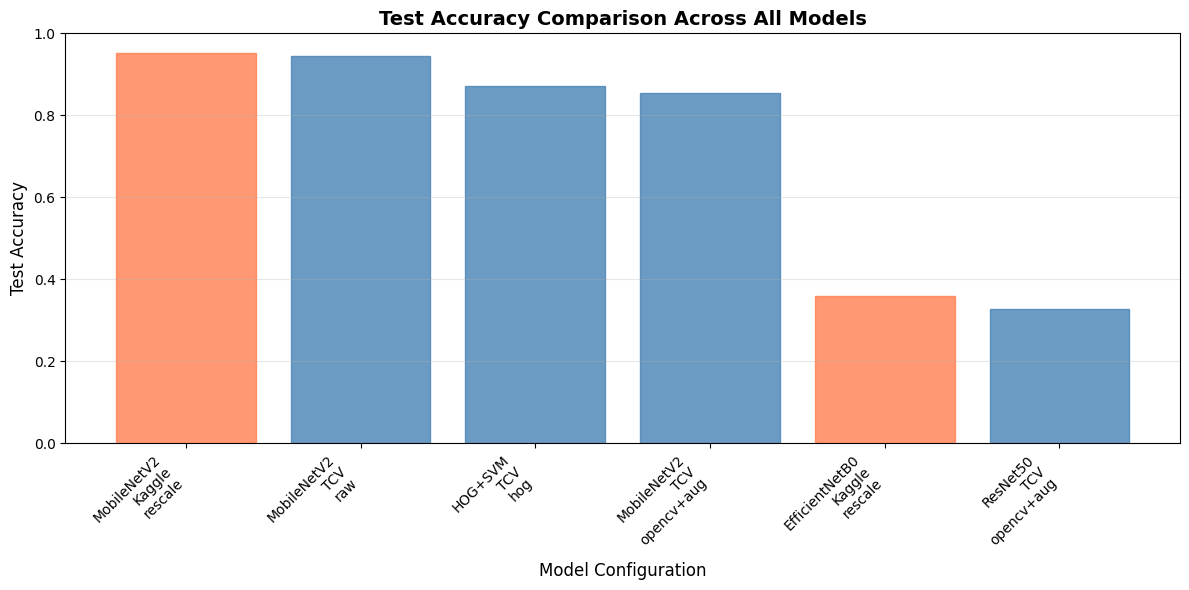

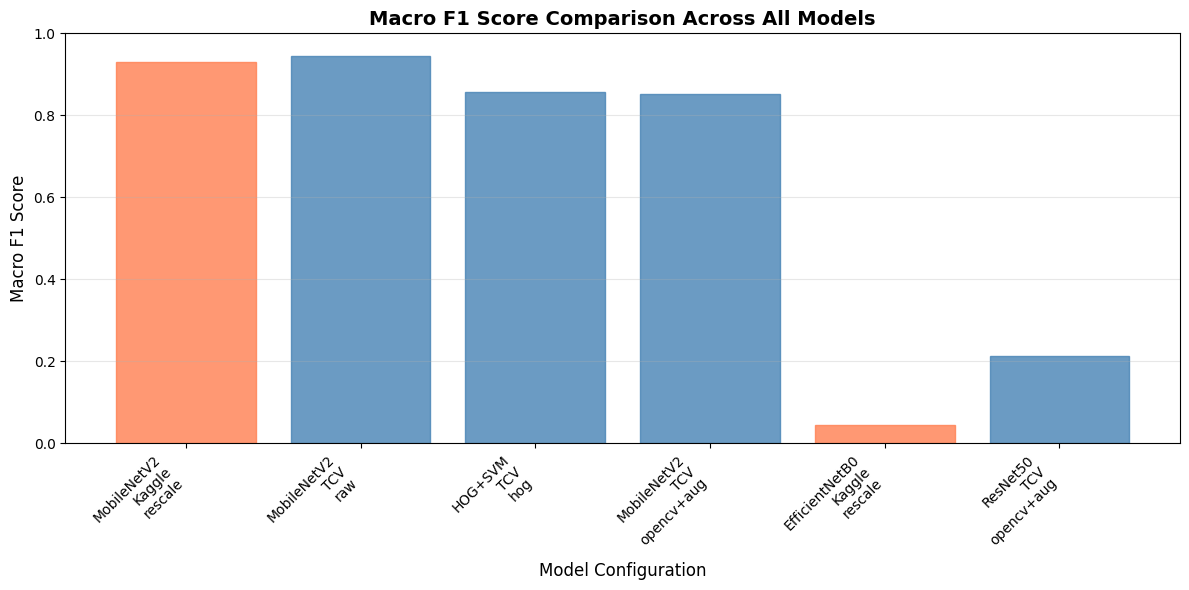

In [26]:

# Plot 1: Test Accuracy Comparison
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(results_df))
bars = plt.bar(x_pos, results_df['test_accuracy'], color='steelblue', alpha=0.8)

# Color-code by dataset
colors = {'TCV': 'steelblue', 'Kaggle': 'coral'}
for i, (idx, row) in enumerate(results_df.iterrows()):
    bars[i].set_color(colors.get(row['dataset'], 'gray'))

plt.xlabel('Model Configuration', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy Comparison Across All Models', fontsize=14, fontweight='bold')
plt.xticks(x_pos, [f"{row['model_name']}\n{row['dataset']}\n{row['preprocessing']}"
                    for _, row in results_df.iterrows()], rotation=45, ha='right')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: F1 Score Comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(x_pos, results_df['test_f1_macro'], color='forestgreen', alpha=0.8)

# Color-code by dataset
for i, (idx, row) in enumerate(results_df.iterrows()):
    bars[i].set_color(colors.get(row['dataset'], 'gray'))

plt.xlabel('Model Configuration', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.title('Macro F1 Score Comparison Across All Models', fontsize=14, fontweight='bold')
plt.xticks(x_pos, [f"{row['model_name']}\n{row['dataset']}\n{row['preprocessing']}"
                    for _, row in results_df.iterrows()], rotation=45, ha='right')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 12. PREPROCESSING IMPACT ANALYSIS



PREPROCESSING IMPACT ANALYSIS

=== Impact of Preprocessing on MobileNetV2 (TCV Dataset) ===
preprocessing  test_accuracy  test_f1_macro
          raw       0.945455       0.944921
   opencv+aug       0.854545       0.852709

Accuracy improvement: -9.09%
F1 score improvement: -9.22%


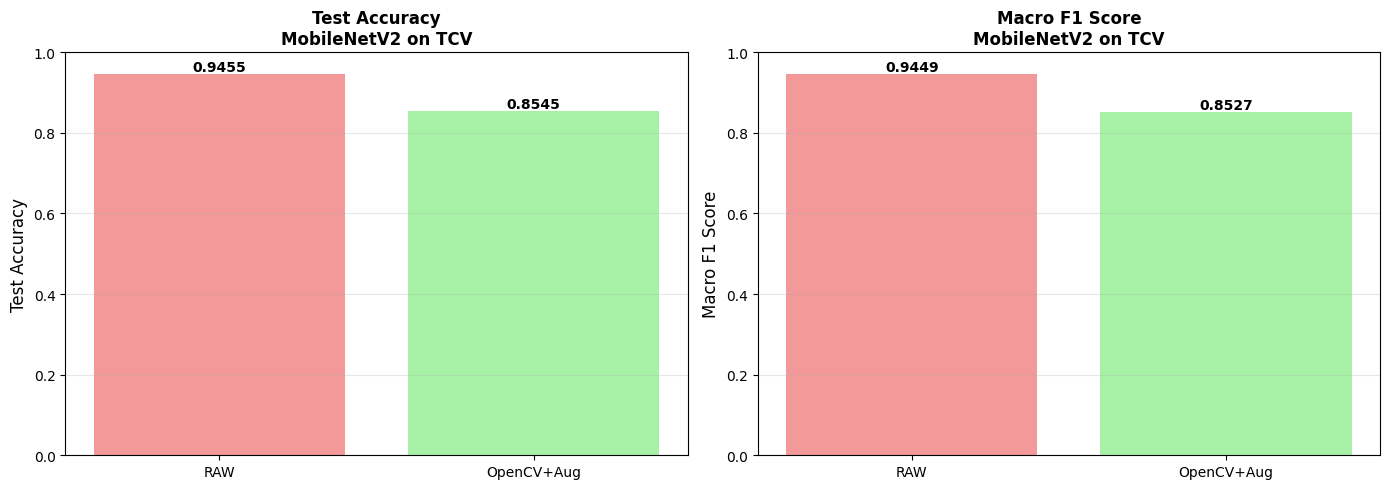

In [27]:

print("\n" + "="*60)
print("PREPROCESSING IMPACT ANALYSIS")
print("="*60)

# Filter MobileNetV2 TCV results
mobilenet_tcv = results_df[
    (results_df['model_name'] == 'MobileNetV2') &
    (results_df['dataset'] == 'TCV')
].copy()

if len(mobilenet_tcv) >= 2:
    print("\n=== Impact of Preprocessing on MobileNetV2 (TCV Dataset) ===")
    print(mobilenet_tcv[['preprocessing', 'test_accuracy', 'test_f1_macro']].to_string(index=False))

    # Calculate improvement
    raw_results = mobilenet_tcv[mobilenet_tcv['preprocessing'] == 'raw'].iloc[0]
    pre_results = mobilenet_tcv[mobilenet_tcv['preprocessing'] == 'opencv+aug'].iloc[0]

    acc_improvement = (pre_results['test_accuracy'] - raw_results['test_accuracy']) * 100
    f1_improvement = (pre_results['test_f1_macro'] - raw_results['test_f1_macro']) * 100

    print(f"\nAccuracy improvement: {acc_improvement:+.2f}%")
    print(f"F1 score improvement: {f1_improvement:+.2f}%")

    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    metrics = ['test_accuracy', 'test_f1_macro']
    metric_names = ['Test Accuracy', 'Macro F1 Score']

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        raw_val = raw_results[metric]
        pre_val = pre_results[metric]

        x = ['RAW', 'OpenCV+Aug']
        y = [raw_val, pre_val]

        bars = ax[i].bar(x, y, color=['lightcoral', 'lightgreen'], alpha=0.8)
        ax[i].set_ylabel(name, fontsize=12)
        ax[i].set_title(f'{name}\nMobileNetV2 on TCV', fontsize=12, fontweight='bold')
        ax[i].set_ylim([0, 1.0])
        ax[i].grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for bar, val in zip(bars, y):
            height = bar.get_height()
            ax[i].text(bar.get_x() + bar.get_width()/2., height,
                      f'{val:.4f}',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


# 13. FINAL SUMMARY TEXT


In [28]:

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

best_model = results_df.iloc[0]
print(f"\nBest Overall Model: {best_model['model_name']} on {best_model['dataset']} dataset")
print(f"  - Preprocessing: {best_model['preprocessing']}")
print(f"  - Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"  - Macro F1 Score: {best_model['test_f1_macro']:.4f}")

# Compare datasets
tcv_avg = results_df[results_df['dataset'] == 'TCV']['test_accuracy'].mean()
kaggle_avg = results_df[results_df['dataset'] == 'Kaggle']['test_accuracy'].mean()

print(f"\nDataset Comparison:")
print(f"  - Average accuracy on TCV dataset: {tcv_avg:.4f}")
print(f"  - Average accuracy on Kaggle dataset: {kaggle_avg:.4f}")

if tcv_avg > kaggle_avg:
    print(f"  - TCV dataset shows {(tcv_avg - kaggle_avg)*100:.2f}% better performance on average")
else:
    print(f"  - Kaggle dataset shows {(kaggle_avg - tcv_avg)*100:.2f}% better performance on average")

# Model comparison
mobilenet_avg = results_df[results_df['model_name'] == 'MobileNetV2']['test_accuracy'].mean()
resnet_avg = results_df[results_df['model_name'] == 'ResNet50']['test_accuracy'].mean()

print(f"\nModel Architecture Comparison:")
print(f"  - MobileNetV2 average accuracy: {mobilenet_avg:.4f}")
print(f"  - ResNet50 average accuracy: {resnet_avg:.4f}")

print("\n" + "="*60)
print("NOTEBOOK EXECUTION COMPLETE!")
print("="*60)


FINAL SUMMARY

Best Overall Model: MobileNetV2 on Kaggle dataset
  - Preprocessing: rescale
  - Test Accuracy: 0.9528
  - Macro F1 Score: 0.9293

Dataset Comparison:
  - Average accuracy on TCV dataset: 0.7500
  - Average accuracy on Kaggle dataset: 0.6563
  - TCV dataset shows 9.37% better performance on average

Model Architecture Comparison:
  - MobileNetV2 average accuracy: 0.9176
  - ResNet50 average accuracy: 0.3273

NOTEBOOK EXECUTION COMPLETE!
